In [5]:
import pandas as pd

df = pd.read_csv('/content/heart_disease_uci.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(920, 16)
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
# Drop unnecessary columns
df = df.drop(columns=['id', 'dataset'])

# Convert target: 0 = no disease, 1 = disease
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

# Fill missing values FIRST
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
df['ca'] = df['ca'].fillna(df['ca'].median())
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])
df['fbs'] = df['fbs'].fillna(False)
df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])
df['exang'] = df['exang'].fillna(False)

# Now convert boolean to int
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

# Encode categorical columns
df = pd.get_dummies(df, columns=['sex', 'cp', 'restecg', 'slope', 'thal'])

print("Cleaned Shape:", df.shape)
print("Missing Values After Cleaning:")
print(df.isnull().sum().sum())

Cleaned Shape: (920, 24)
Missing Values After Cleaning:
0


/tmp/ipykernel_24834/1257386829.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'] = df['fbs'].fillna(False)
/tmp/ipykernel_24834/1257386829.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].fillna(False)


/tmp/ipykernel_24834/223602877.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target',


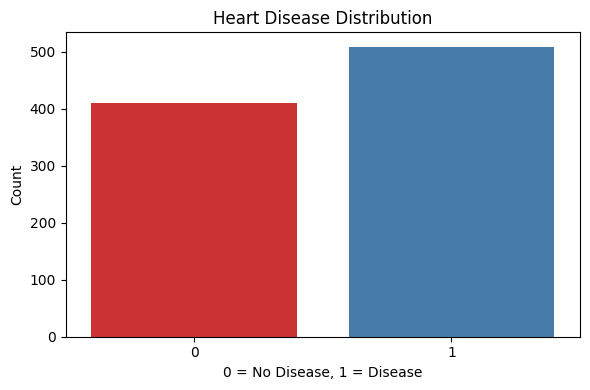

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target',
              palette='Set1')
plt.title('Heart Disease Distribution')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

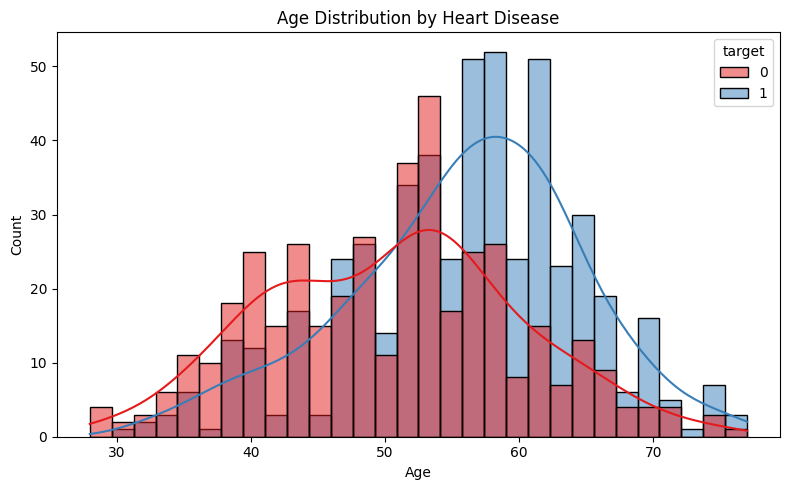

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='target',
             bins=30, palette='Set1', kde=True)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

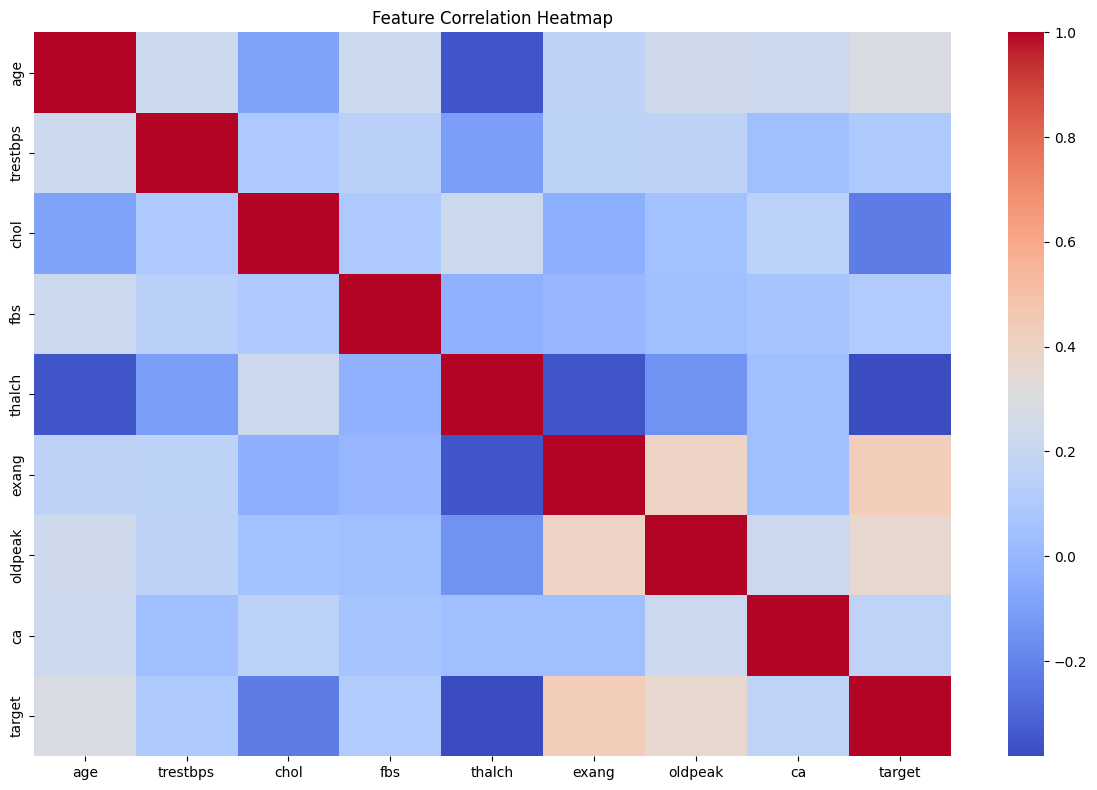

In [9]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),
            cmap='coolwarm',
            annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(columns='target')
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train both models
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


In [11]:
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)

# Predictions
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test, lr_pred), 4))
print("Decision Tree Accuracy:",
      round(accuracy_score(y_test, dt_pred), 4))

# ROC AUC
print("\nLogistic Regression ROC-AUC:",
      round(roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]), 4))
print("Decision Tree ROC-AUC:",
      round(roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]), 4))

Logistic Regression Accuracy: 0.7989
Decision Tree Accuracy: 0.7989

Logistic Regression ROC-AUC: 0.8871
Decision Tree ROC-AUC: 0.7949


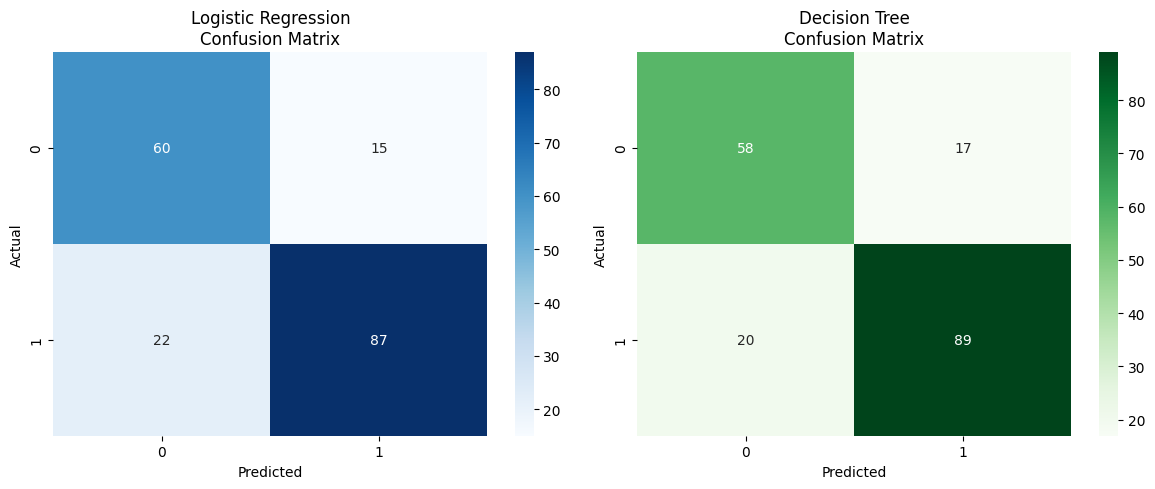

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True, fmt='d',
            cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

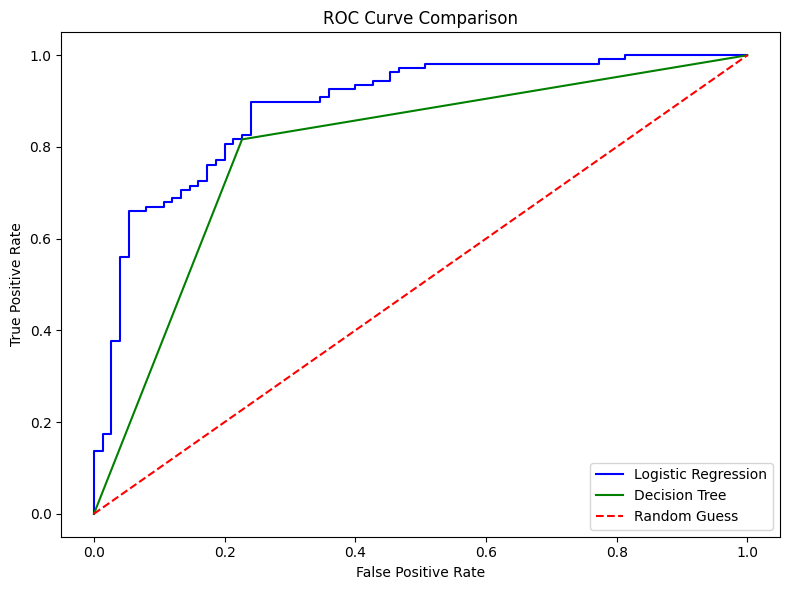

In [13]:
plt.figure(figsize=(8,6))

# Logistic Regression ROC
fpr, tpr, _ = roc_curve(
    y_test, lr.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label='Logistic Regression', color='blue')

# Decision Tree ROC
fpr2, tpr2, _ = roc_curve(
    y_test, dt.predict_proba(X_test)[:,1])
plt.plot(fpr2, tpr2, label='Decision Tree', color='green')

plt.plot([0,1],[0,1],'r--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_24834/2347281072.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values,


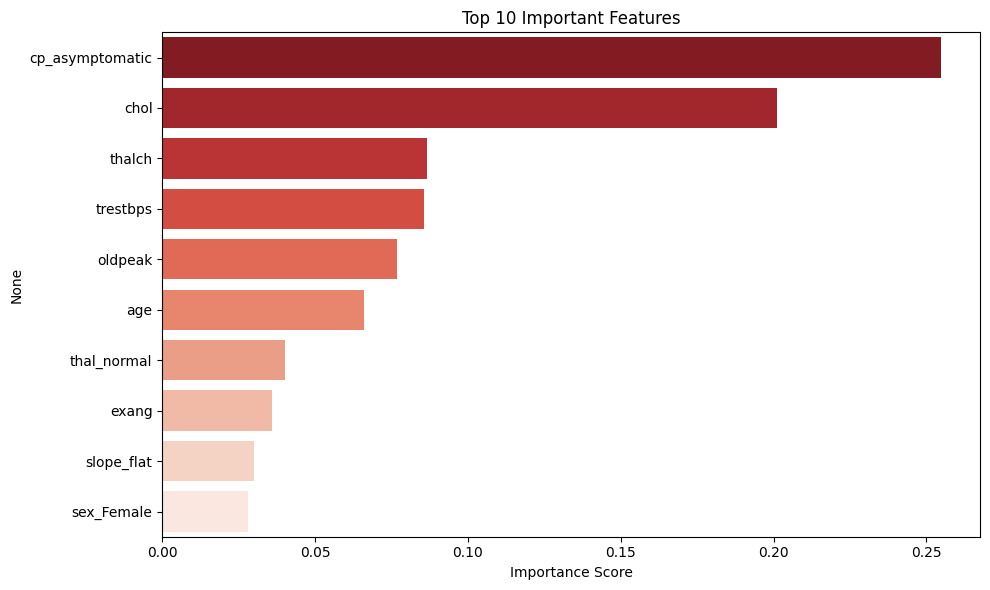

In [14]:
# Feature importance from Decision Tree
feature_names = df.drop(columns='target').columns
importances = pd.Series(
    dt.feature_importances_,
    index=feature_names
).sort_values(ascending=False)[:10]

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values,
            y=importances.index,
            palette='Reds_r')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()